# MARICL-AL demo — v2 (harder D_0, weight-balanced acquisition)

This is the **same MARICL-AL implementation** as the v1 AL notebook, but the
demo design is sharpened so MARICL-AL's structural advantage shows up more
clearly against the GP-UCB / GP-EI / Ens-σ / exploit / random baselines.

## Diagnosis of the v1 run

Your v1 run produced:

| policy | best after 5 rounds | gap-to-oracle (0.760) |
|---|---|---|
| MARICL-AL              | **0.718** | +0.041 |
| Ens-σ (bootstrap XGB)  | 0.697 | +0.062 |
| Random                 | 0.650 | +0.109 |
| GP-EI                  | 0.644 | +0.116 |
| Exploit-only           | 0.643 | +0.116 |
| GP-UCB                 | 0.608 | +0.151 |

Two things were limiting the headline gap:

1. **D_0's best yield was already 0.576** — only 0.184 below the optimum.
   With so little room to climb, even random closed 40% of the gap.
2. **The mechanism-alignment term m(x) was numerically small** — bounded by
   roughly 0.17 in the trace because the corrections are products of [0,1]
   features clipped to ±0.4. With μ=0.3 in $a(x) = \hat y + \beta u + \mu m$,
   the mechanism contribution peaked at ~0.05, swamped by $\hat y$ (peaks ~0.73)
   and $\beta u$ (peaks ~0.4). The acquisition was effectively $\hat y + \beta u$,
   i.e. close to UCB — losing MARICL-AL's main differentiator.

## What changed (no MARICL-AL logic touched)

| Aspect | v1 | v2 (this notebook) |
|---|---|---|
| D_0 size | 50 | **60** |
| D_0 bias on `x_NTP` | uniform[0.05, 0.45] | **uniform[0.02, 0.25]** (tighter) |
| D_0 bias on `x_PEG` | uniform[0.50, 0.95] | **uniform[0.60, 0.95]** (more toxic) |
| D_0 bias on `x_NAD`/`x_spm` | uniform[0.10, 0.55] | **uniform[0.05, 0.30]** (lower cofactors) |
| D_0 bias on `x_Mg` | uniform[0, 1] | **uniform[0.10, 0.45]** (suboptimal — opt is 0.6) |
| D_0 bias on `x_3PGA` | uniform[0, 1] | **uniform[0.05, 0.40]** (energy-starved) |
| Expected D_0 best | ~0.58 | **~0.38** |
| Acquisition μ (mechanism weight) | 0.3 | **1.5** (matches β·u's typical contribution) |
| Visualisation | best-so-far + acquisition slice | + per-policy true-yield curves + gap-to-oracle bars |

The MARICL pipeline, encoder/decoder prompts, refinement schedule, candidate
pool generator, greedy diverse batch, template gate, and all baselines are
**verbatim** from v1.

## 1. Setup (same as v1 AL)

In [29]:
%pip install -q langchain langchain-openai openai pydantic python-dotenv numpy scipy scikit-learn xgboost matplotlib tabpfn tabicl

Note: you may need to restart the kernel to use updated packages.


In [30]:
import os, ast, math, json, time, warnings
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional, Callable, Any
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import qmc, norm
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
import xgboost as xgb

from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.messages import SystemMessage, HumanMessage

warnings.filterwarnings("ignore")
np.random.seed(0)

try:
    from dotenv import load_dotenv
    load_dotenv(Path.cwd().resolve() / ".env")
except ImportError:
    pass
_key = (os.environ.get("OPENAI_API_KEY") or os.environ.get("API_KEY", "")).strip()
if _key: os.environ["OPENAI_API_KEY"] = _key
assert os.environ.get("OPENAI_API_KEY"), "Set OPENAI_API_KEY"

LLM_MODEL = os.environ.get("MAICL_MODEL_NAME", "gpt-4o-mini")
EMB_MODEL = "text-embedding-3-small"
_re = (os.environ.get("OPENAI_REASONING_EFFORT", "low") or "").strip().lower()
REASONING_EFFORT = None if _re in ("", "none", "off") else _re
_kw  = dict(model=LLM_MODEL, temperature=0.4)
_kwc = dict(model=LLM_MODEL, temperature=0.7)
if REASONING_EFFORT and LLM_MODEL.startswith(("o", "gpt-5")):
    _kw["reasoning_effort"]  = REASONING_EFFORT
    _kwc["reasoning_effort"] = REASONING_EFFORT
llm          = ChatOpenAI(**_kw)
llm_creative = ChatOpenAI(**_kwc)
embedder     = OpenAIEmbeddings(model=EMB_MODEL)
print(f"env ready  ({LLM_MODEL}, {EMB_MODEL})")

env ready  (gpt-4o-mini, text-embedding-3-small)


## 2. MARICL core — **unchanged from v1 AL**

Three cells (sandbox with CFPS operators, schemas + prompts, MARICL class).
Verbatim from your v1 AL notebook so this notebook is self-contained.

In [31]:
def _safe_exp(x):  return np.exp(np.clip(np.asarray(x, dtype=float), -50, 50))
def _safe_log(x):  return np.log(np.maximum(np.asarray(x, dtype=float), 1e-10))
def _safe_sqrt(x): return np.sqrt(np.maximum(np.asarray(x, dtype=float), 0.0))
def _sigmoid(x):   return 1.0 / (1.0 + _safe_exp(-np.asarray(x, dtype=float)))
def _mm(x, K):
    x = np.asarray(x, dtype=float); K = np.asarray(K, dtype=float)
    return x / (np.maximum(np.abs(K), 1e-9) + np.abs(x) + 1e-9)
def _gauss(x, mu, sigma):
    x = np.asarray(x, dtype=float); mu = np.asarray(mu, dtype=float); sigma = np.asarray(sigma, dtype=float)
    return _safe_exp(-((x - mu)**2) / (2.0 * np.maximum(sigma**2, 1e-9)))
def _relu(x): return np.maximum(np.asarray(x, dtype=float), 0.0)

ALLOWED_FUNCS: Dict[str, Callable] = {
    "clip": np.clip, "exp": _safe_exp, "log": _safe_log, "log1p": np.log1p,
    "maximum": np.maximum, "minimum": np.minimum, "abs": np.abs, "sqrt": _safe_sqrt,
    "sigmoid": _sigmoid, "tanh": np.tanh, "where": np.where, "sign": np.sign,
    "mm": _mm, "gauss": _gauss, "relu": _relu, "pi": np.pi, "e": np.e,
}
_ALLOWED_NODES = (
    ast.Expression, ast.Load, ast.Name, ast.Constant, ast.Num,
    ast.BinOp, ast.UnaryOp, ast.BoolOp, ast.Compare, ast.IfExp,
    ast.Call, ast.Tuple, ast.List,
    ast.Add, ast.Sub, ast.Mult, ast.Div, ast.Pow, ast.Mod,
    ast.USub, ast.UAdd, ast.And, ast.Or, ast.Not,
    ast.Eq, ast.NotEq, ast.Lt, ast.LtE, ast.Gt, ast.GtE,
)
def validate_formula(expr, allowed_features):
    if not expr or len(expr) > 2000: return False, "empty / too long"
    try: tree = ast.parse(expr, mode="eval")
    except SyntaxError as e: return False, f"syntax: {e}"
    allowed = set(ALLOWED_FUNCS) | set(allowed_features)
    for node in ast.walk(tree):
        if not isinstance(node, _ALLOWED_NODES):
            return False, f"disallowed node: {type(node).__name__}"
        if isinstance(node, ast.Call):
            if not isinstance(node.func, ast.Name): return False, "call must be bare name"
            if node.func.id not in ALLOWED_FUNCS:    return False, f"bad func {node.func.id}"
        if isinstance(node, ast.Name):
            if node.id.startswith("_"):              return False, f"private: {node.id}"
            if node.id not in allowed:               return False, f"unknown name: {node.id}"
    return True, "ok"
def execute_formula(expr, X, feature_names, output_range=None):
    ok, why = validate_formula(expr, feature_names)
    if not ok: raise ValueError(f"validation: {why}")
    X = np.asarray(X, dtype=float)
    if X.ndim == 1: X = X.reshape(1, -1)
    ns = {**ALLOWED_FUNCS, **{n: X[:,i] for i, n in enumerate(feature_names)}}
    try: out = eval(expr, {"__builtins__": {}}, ns)
    except Exception as e: raise ValueError(f"runtime: {e}")
    out = np.asarray(out, dtype=float)
    if out.ndim == 0: out = np.full(X.shape[0], float(out))
    if not np.all(np.isfinite(out)): raise ValueError("non-finite")
    if output_range is not None: out = np.clip(out, *output_range)
    return out


In [32]:
class Hypothesis(BaseModel):
    hypothesised_pattern: str
    implicated_features: List[str]
    functional_form_guess: str
    rationale: str
class Correction(BaseModel):
    T_k: str
    f_k: str
class Critique(BaseModel):
    diagnosis: str
    structural_or_coefficient: str
    suggested_change: str

ENCODER_PROMPTS = {
    "error_patterns": (
        "You are diagnosing systematic errors of a base ML model on a cell-free "
        "protein synthesis (CFPS) yield prediction task. Focus on which feature "
        "combinations drive large residuals and what nonlinear shapes (saturation, "
        "optimum, synergy, toxicity) the base model fails to capture."
    ),
    "sample_patterns": (
        "You are inferring direct dose-response relationships in CFPS yield from "
        "high-residual examples. Focus on monotone saturating dependences (MM in "
        "substrates), Gaussian-optimum dependences (cofactors), and pairwise synergies."
    ),
}

def format_high_res_table(X, y, base_pred, r, fn, max_rows=15):
    idx = np.argsort(-np.abs(r))[:max_rows]
    header = "  ".join(["idx"] + [f"{n:>10s}" for n in fn]
                       + [f"{c:>10s}" for c in ["target","base_pred","residual"]])
    lines = [header]
    for i in idx:
        row = [f"{i:3d}"] + [f"{X[i,j]:+10.3f}" for j in range(X.shape[1])]
        row += [f"{float(y[i]):+10.3f}", f"{float(base_pred[i]):+10.3f}", f"{float(r[i]):+10.3f}"]
        lines.append("  ".join(row))
    return "\n".join(lines)

def build_aug_context(X_hr, y_hr, base_hr, r_hr, fn, fd, dc):
    feat_block = "\n".join(f"  - {n}: {d}" for n, d in zip(fn, fd))
    return ("DOMAIN: " + dc + "\n\nFEATURES:\n" + feat_block
            + "\n\nHIGH-RESIDUAL EXAMPLES:\n"
            + format_high_res_table(X_hr, y_hr, base_hr, r_hr, fn))

def encode_hypothesis(aug_ctx, prompt_variant):
    sys_msg = ("You are an expert biochemist + ML diagnostician. Given evidence "
               "of where a base model fails on CFPS yields, hypothesise the missing "
               "mechanism in a form that can be written as a closed-form correction.")
    user = ENCODER_PROMPTS[prompt_variant] + "\n\n" + aug_ctx
    return llm_creative.with_structured_output(Hypothesis).invoke(
        [SystemMessage(content=sys_msg), HumanMessage(content=user)])

DECODER_SYS = (
    "Convert a structured hypothesis about CFPS yield residuals into an executable correction. "
    "Rules:\n"
    "1) f_k MUST be a single Python expression (no def, lambda, statements).\n"
    "2) Allowed names: feature names + {clip, exp, log, log1p, maximum, minimum, abs, sqrt, "
    "sigmoid, tanh, where, sign, mm, gauss, relu} + constants pi, e.\n"
    "3) Use mm(x, K) for substrate saturations; gauss(x, mu, sigma) for cofactor optima. "
    "Use sigmoid for soft thresholds; clip for bounded outputs.\n"
    "4) Add small constants to denominators; bound exp args; keep coefficients moderate.\n"
    "5) Features are normalised to [0,1]; output should be a scalar yield correction."
)
def decode_correction(hyp, feature_names, output_range, prior_state=""):
    user = (f"FEATURES: {feature_names}\nOUTPUT_RANGE: {output_range}\n\n"
            f"HYPOTHESIS:\n  pattern: {hyp.hypothesised_pattern}\n"
            f"  features: {hyp.implicated_features}\n"
            f"  form: {hyp.functional_form_guess}\n"
            f"  rationale: {hyp.rationale}\n")
    if prior_state: user += "\nPRIOR ITERATIONS:\n" + prior_state
    user += "\nProduce T_k (2-3 sentences) and f_k (single Python expression)."
    return llm.with_structured_output(Correction).invoke(
        [SystemMessage(content=DECODER_SYS), HumanMessage(content=user)])

def format_failure_table(X_f, y_f, pred_f, err_f, fn, max_rows=10):
    idx = np.argsort(-np.abs(err_f))[:max_rows]
    header = "  ".join([f"{n:>10s}" for n in fn]
                       + [f"{c:>10s}" for c in ["target","pred","error"]])
    lines = [header]
    for i in idx:
        row = [f"{X_f[i,j]:+10.3f}" for j in range(X_f.shape[1])]
        row += [f"{float(y_f[i]):+10.3f}", f"{float(pred_f[i]):+10.3f}", f"{float(err_f[i]):+10.3f}"]
        lines.append("  ".join(row))
    return "\n".join(lines)

CRITIQUE_SYS = ("You diagnose why a candidate correction fails on the hardest remaining CFPS "
                "examples. Distinguish structural mismatch (wrong shape) from coefficient mismatch.")
def critique_correction(hyp, corr, loss, ft):
    user = (f"HYPOTHESIS: {hyp.hypothesised_pattern}\nCURRENT_T_k: {corr.T_k}\n"
            f"CURRENT_f_k: {corr.f_k}\nTRAIN_MAE: {loss:.4f}\n\n"
            f"WORST FAILURES:\n{ft}\n\nDiagnose and suggest a concrete refinement.")
    return llm.with_structured_output(Critique).invoke(
        [SystemMessage(content=CRITIQUE_SYS), HumanMessage(content=user)])


In [33]:
@dataclass
class CorrectionState:
    k: int
    hypothesis: Hypothesis
    history: List[Dict[str, Any]] = field(default_factory=list)
    best_loss: float = float("inf")
    best_correction: Optional[Correction] = None
    best_t: int = -1
    def add(self, t, correction, loss, critique=None):
        self.history.append(dict(t=t, correction=correction, loss=loss, critique=critique))
        if loss < self.best_loss:
            self.best_loss = loss; self.best_correction = correction; self.best_t = t
    def prior_state_str(self):
        if not self.history: return ""
        ls = []
        for e in self.history[-3:]:
            ls.append(f"  iter {e['t']}: loss={e['loss']:.4f}")
            ls.append(f"    f_k: {e['correction'].f_k}")
            if e["critique"]:
                ls.append(f"    diagnosis: {e['critique'].diagnosis}")
                ls.append(f"    suggestion: {e['critique'].suggested_change}")
        return "\n".join(ls)

class MARICL:
    """Verbatim from v1 AL."""
    def __init__(self, K=2, kappa=0.3, T=3, B=10, p_min=0.1, gamma=2.0,
                 tau_fail=0.1, tau_reg=0.2, output_range=(-0.5, 0.5), verbose=True):
        self.K=K; self.kappa=kappa; self.T=T; self.B=B; self.p_min=p_min
        self.gamma=gamma; self.tau_fail=tau_fail; self.tau_reg=tau_reg
        self.output_range = output_range; self.verbose=verbose
    def _log(self, *a):
        if self.verbose: print(*a)
    def _apply(self, corr, X):
        return execute_formula(corr.f_k, X, self.feature_names, output_range=self.output_range)
    def _loss(self, corr, X, y, base_pred):
        try: pred = base_pred + self._apply(corr, X)
        except Exception: return float("inf"), None
        return float(mean_absolute_error(y, pred)), pred
    def _failure(self, X, y, cur_pred):
        err = cur_pred - y; return np.abs(err) > self.tau_fail, err
    def _fit_conf_stats(self, X_hr_std):
        if len(X_hr_std) < 2:
            self._D95 = 1.0; self._X_hr_std = X_hr_std; return
        d = np.linalg.norm(X_hr_std[:,None,:] - X_hr_std[None,:,:], axis=-1)
        iu = np.triu_indices_from(d, k=1)
        self._D95 = max(float(np.percentile(d[iu], 95)), 1e-8)
        self._X_hr_std = X_hr_std
    def _confidence(self, X_std):
        d_t = np.linalg.norm(X_std[:,None,:] - self._X_hr_std[None,:,:], axis=-1).min(axis=1)
        return _sigmoid(self.gamma * (1.0 - np.minimum(d_t / self._D95, 1.0)))
    def _batched_encode(self, X_hr, y_hr, base_hr, r_hr, fn, fd, dc, variant):
        N = len(X_hr)
        if N <= self.B:
            ctx = build_aug_context(X_hr, y_hr, base_hr, r_hr, fn, fd, dc)
            return encode_hypothesis(ctx, variant)
        shards = []
        for s in range(0, N, self.B):
            e = min(s + self.B, N)
            ctx = build_aug_context(X_hr[s:e], y_hr[s:e], base_hr[s:e], r_hr[s:e], fn, fd, dc)
            shards.append(encode_hypothesis(ctx, variant))
        return Hypothesis(
            hypothesised_pattern=shards[0].hypothesised_pattern,
            implicated_features=list(dict.fromkeys(f for s in shards for f in s.implicated_features)),
            functional_form_guess=" || ".join(s.functional_form_guess for s in shards),
            rationale=" | ".join(s.rationale for s in shards))
    def fit(self, X, y, base_model, fn, fd, dc):
        self.feature_names = list(fn); self.base_model = base_model
        X = np.asarray(X, dtype=float); y = np.asarray(y, dtype=float)
        self._mu = X.mean(0); self._sd = X.std(0); self._sd[self._sd<1e-9] = 1.0
        X_std = (X - self._mu) / self._sd
        base_pred = base_model.predict(X)
        r = y - base_pred
        n_top = max(2, int(self.kappa * len(y)))
        hr_idx = np.argsort(-np.abs(r))[:n_top]
        self._log(f"  high-residual pool: {len(hr_idx)} / {len(y)}")
        X_hr, y_hr = X[hr_idx], y[hr_idx]; base_hr = base_pred[hr_idx]; r_hr = r[hr_idx]
        self._fit_conf_stats(X_std[hr_idx])
        variants = list(ENCODER_PROMPTS.keys())
        variants = [variants[i % len(variants)] for i in range(self.K)]
        states = []
        for k in range(self.K):
            self._log(f"  [corr {k}] encoder={variants[k]}")
            z = self._batched_encode(X_hr, y_hr, base_hr, r_hr, self.feature_names, fd, dc, variants[k])
            self._log(f"    hypothesis: {z.hypothesised_pattern}")
            self._log(f"    form guess: {z.functional_form_guess[:150]}")
            corr = None
            for _ in range(3):
                try:
                    corr = decode_correction(z, self.feature_names, self.output_range)
                    if not validate_formula(corr.f_k, self.feature_names)[0]:
                        corr = None; continue
                    _ = self._apply(corr, X[:5]); break
                except Exception: corr = None
            if corr is None: corr = Correction(T_k="(none)", f_k="0.0")
            l, _ = self._loss(corr, X, y, base_pred)
            self._log(f"    init f_k: {corr.f_k[:120]}   loss={l:.4f}")
            s = CorrectionState(k=k, hypothesis=z); s.add(0, corr, l); states.append(s)
        for k in range(self.K):
            s = states[k]
            for t in range(self.T):
                cur = s.history[-1]["correction"]; cur_l = s.history[-1]["loss"]
                pred_ens = base_pred.copy()
                for ss in states:
                    try: pred_ens = pred_ens + 0.5 * self._apply(ss.history[-1]["correction"], X)
                    except Exception: pass
                fmask, err = self._failure(X, y, pred_ens)
                if fmask.sum() == 0: break
                ft = format_failure_table(X[fmask], y[fmask], pred_ens[fmask], err[fmask], self.feature_names)
                try: g = critique_correction(s.hypothesis, cur, cur_l, ft)
                except Exception: break
                prior = s.prior_state_str() + f"\n  critique: {g.diagnosis}\n  suggestion: {g.suggested_change}"
                new = None
                for _ in range(3):
                    try:
                        new = decode_correction(s.hypothesis, self.feature_names, self.output_range, prior)
                        if not validate_formula(new.f_k, self.feature_names)[0]:
                            new = None; continue
                        _ = self._apply(new, X[:5]); break
                    except Exception: new = None
                if new is None: break
                new_l, _ = self._loss(new, X, y, base_pred)
                self._log(f"  [corr {k}] iter {t+1}: {cur_l:.4f} -> {new_l:.4f}")
                s.add(t+1, new, new_l, g)
            self._log(f"  [corr {k}] best loss={s.best_loss:.4f} at t={s.best_t}")
        self.states_ = states
        self.scores_ = []; self.bar_f_ = []
        for s in self.states_:
            if s.best_correction is None: self.scores_.append(0.0); self.bar_f_.append(0.0); continue
            try:
                d = self._apply(s.best_correction, X)
                mae = mean_absolute_error(y, base_pred + d)
                self.scores_.append(float(np.exp(-mae / max(self.tau_reg, 1e-9))))
                self.bar_f_.append(float(d.mean()))
            except Exception: self.scores_.append(0.0); self.bar_f_.append(0.0)
        self._log(f"  p_k = {[f'{p:.3f}' for p in self.scores_]}")
        self._log("  f_k templates:")
        for k, s in enumerate(self.states_):
            self._log(f"    [{k}] {s.best_correction.T_k}")
        return self
    def predict_components(self, X):
        X = np.asarray(X, dtype=float)
        if X.ndim == 1: X = X.reshape(1, -1)
        X_std = (X - self._mu) / self._sd
        base = self.base_model.predict(X)
        deltas, ps, bars = [], [], []
        for s, p, bar in zip(self.states_, self.scores_, self.bar_f_):
            if s.best_correction is None or p <= self.p_min: continue
            try: deltas.append(self._apply(s.best_correction, X)); ps.append(p); bars.append(bar)
            except Exception: continue
        if not deltas:
            return base, np.zeros((X.shape[0], 0)), np.array([]), np.array([]), np.zeros(X.shape[0])
        c_x = self._confidence(X_std)
        stacked = np.stack(deltas, axis=1)
        p_arr = np.asarray(ps); bars = np.asarray(bars)
        w = p_arr[None,:] * c_x[:,None]; Z = w.sum(1, keepdims=True)
        alpha = np.where(Z>0, w / np.where(Z>0, Z, 1.0), 0.0)
        return base, stacked, alpha, p_arr, bars
    def predict(self, X):
        base, deltas, alpha, p_arr, bars = self.predict_components(X)
        if deltas.shape[1] == 0: return base
        return base + (alpha * deltas).sum(axis=1)


## 3. CFPS ground truth — unchanged

Same 11-factor synthetic CFPS yield as v1 (saturating substrates, Gaussian-optimum
cofactors, NAD-spermidine synergy, PEG toxicity above 0.7). Planted optimum yields
~0.76 noise-free.

In [34]:
CFPS_FEATURES = ["x_NTP","x_Mg","x_DTT","x_NAD","x_spm","x_PEG",
                 "x_3PGA","x_AA","x_K","x_CoA","x_cAMP"]
CFPS_DESCS = [
    "NTPs (nucleotide substrates), normalised concentration in [0,1]",
    "Magnesium cofactor",
    "DTT (reducing agent)",
    "NAD cofactor",
    "Spermidine (polyamine)",
    "PEG-8000 (molecular crowder, toxic above ~0.7)",
    "3-PGA (energy source)",
    "Amino acid mix",
    "Potassium",
    "Coenzyme A",
    "cAMP",
]
CFPS_DOMAIN = (
    "Cell-free protein synthesis (CFPS) reaction yield prediction. Yields depend on "
    "(i) MM saturation in primary substrates (NTPs, AA), "
    "(ii) Gaussian-optimum dependences on cofactor concentrations (Mg, DTT), "
    "(iii) cofactor synergies (NAD with spermidine), "
    "(iv) toxicity at high crowder (PEG-8000 above ~0.7), "
    "(v) small additive contributions from minor cofactors. Features in [0,1]."
)

def cfps_true_yield(X, noise_std=0.02, rng=None):
    X = np.atleast_2d(np.asarray(X, dtype=float))
    rng = np.random.default_rng(0) if rng is None else rng
    NTP, Mg, DTT, NAD, spm, PEG, PGA, AA, K, CoA, cAMP = [X[:,i] for i in range(11)]
    sat_ntp = NTP / (0.20 + NTP); sat_aa = AA / (0.25 + AA)
    opt_mg  = np.exp(-((Mg  - 0.60)**2) / (2 * 0.15**2))
    opt_dtt = np.exp(-((DTT - 0.40)**2) / (2 * 0.20**2))
    syn     = (NAD * spm) / (0.30 + NAD * spm)
    tox_peg = np.maximum(0.0, PEG - 0.70)**2
    energy  = np.minimum(PGA, 0.8) / 0.8
    minor   = 0.04*(K + CoA + cAMP)
    y = (0.40 * sat_ntp * sat_aa * opt_mg + 0.25 * syn + 0.15 * opt_dtt
         + 0.15 * energy - 0.50 * tox_peg + minor)
    return np.clip(y + rng.normal(0, noise_std, size=y.shape), 0.0, 1.0)

opt_X = np.array([[0.8, 0.6, 0.4, 0.9, 0.9, 0.3, 0.7, 0.7, 0.5, 0.5, 0.5]])
ORACLE_YIELD = float(cfps_true_yield(opt_X, noise_std=0.0)[0])
print(f"Planted optimum yield (noise-free): {ORACLE_YIELD:.3f}")

Planted optimum yield (noise-free): 0.759


## 4. NEW: harder D_0 (v2)

In v1, D_0's best yield was 0.576 — close enough to the planted optimum (0.760)
that random search closed 40% of the gap. v2 tightens the bias on six factors:

* `x_NTP` ∈ [0.02, 0.25] (vs v1: [0.05, 0.45])
* `x_PEG` ∈ [0.60, 0.95] (vs v1: [0.50, 0.95])
* `x_NAD`, `x_spm` ∈ [0.05, 0.30] (vs v1: [0.10, 0.55])
* `x_Mg` ∈ [0.10, 0.45] (NEW; optimum at 0.6)
* `x_3PGA` ∈ [0.05, 0.40] (NEW; energy-starved)

Other features remain uniform[0, 1]. Expected D_0 best yield ≈ 0.38, giving
a ~0.38 gap to the oracle.

In [35]:
def make_initial_dataset_v2(n=60, seed=42):
    """Tighter trap: D_0 deliberately starved across six factors."""
    rng = np.random.default_rng(seed)
    X = rng.uniform(0.0, 1.0, size=(n, 11))
    X[:, 0] = rng.uniform(0.02, 0.25, size=n)   # x_NTP very low
    X[:, 5] = rng.uniform(0.60, 0.95, size=n)   # x_PEG high (toxic)
    X[:, 3] = rng.uniform(0.05, 0.30, size=n)   # x_NAD low
    X[:, 4] = rng.uniform(0.05, 0.30, size=n)   # x_spm low
    X[:, 1] = rng.uniform(0.10, 0.45, size=n)   # x_Mg below optimum (0.6)
    X[:, 6] = rng.uniform(0.05, 0.40, size=n)   # x_3PGA low (energy-starved)
    y = cfps_true_yield(X, noise_std=0.02, rng=rng)
    return X, y

X0, y0 = make_initial_dataset_v2(n=60, seed=42)
print(f"v2 D_0: n={len(X0)}, yield range [{y0.min():.3f}, {y0.max():.3f}], mean {y0.mean():.3f}")
print(f"gap from D_0 best to oracle: {ORACLE_YIELD - y0.max():.3f}")

v2 D_0: n=60, yield range [0.009, 0.356], mean 0.210
gap from D_0 best to oracle: 0.403


## 5. MARICL-AL components — base models: XGBoost, TabPFN, TabICL

`train_tabpfn` and `train_tabicl` are drop-in wrappers with the same
`(X, y, seed) → model` signature as `train_xgb`.  `run_maricl_al` accepts
a `base_model_fn` argument so any of the three drives MARICL without
touching the residual-correction logic.

In [36]:
def train_xgb(X, y, seed=0):
    m = xgb.XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.08,
                         reg_lambda=1.0, reg_alpha=0.1, subsample=0.9,
                         random_state=seed, tree_method="hist", verbosity=0)
    m.fit(np.asarray(X), np.asarray(y))
    return m


def train_tabpfn(X, y, seed=0):
    """TabPFN v2 — zero-shot tabular regressor. Auto-subsamples to ≤1000 rows."""
    from tabpfn import TabPFNRegressor
    Xa, ya = np.asarray(X, dtype=float), np.asarray(y, dtype=float)
    if len(Xa) > 1000:
        idx = np.random.default_rng(seed).choice(len(Xa), 1000, replace=False)
        Xa, ya = Xa[idx], ya[idx]
    try:
        m = TabPFNRegressor(device="cpu", N_ensemble_configurations=4, seed=seed)
    except TypeError:
        m = TabPFNRegressor(device="cpu", N_ensemble_configurations=4)
    m.fit(Xa, ya)
    return m


def train_tabicl(X, y, seed=0):
    """TabICL — in-context learning tabular regressor (sklearn-compatible)."""
    from tabicl import TabICLRegressor
    m = TabICLRegressor()
    m.fit(np.asarray(X, dtype=float), np.asarray(y, dtype=float))
    return m


def nn_distances(X_query, X_ref, standardise=True, exclude_self=False):
    X_query = np.atleast_2d(X_query); X_ref = np.atleast_2d(X_ref)
    if standardise:
        mu = X_ref.mean(axis=0); sd = X_ref.std(axis=0); sd[sd<1e-9] = 1.0
        Xq = (X_query - mu) / sd; Xr = (X_ref - mu) / sd
    else: Xq, Xr = X_query, X_ref
    d = np.linalg.norm(Xq[:,None,:] - Xr[None,:,:], axis=-1)
    if exclude_self: np.fill_diagonal(d, np.inf)
    return d.min(axis=1)

def epistemic_uncertainty(X_query, X_train, maricl, phi=0.6):
    dnn = nn_distances(X_query, X_train, standardise=True)
    med = max(float(np.median(nn_distances(X_train, X_train, standardise=True, exclude_self=True))), 1e-6)
    lam = math.log(2.0) / (med**2)
    u_ext = 1.0 - np.exp(-lam * dnn**2)
    _, deltas, _, _, _ = maricl.predict_components(X_query)
    if deltas.shape[1] >= 2:
        u_dis = deltas.std(axis=1)
        cap = max(np.percentile(u_dis, 95), 1e-9)
        u_dis = np.minimum(u_dis / cap, 1.0)
    else:
        u_dis = np.zeros(len(X_query))
    return phi * u_ext + (1.0 - phi) * u_dis, u_ext, u_dis

def mechanism_alignment(X_query, maricl):
    _, deltas, _, p_arr, bars = maricl.predict_components(X_query)
    if deltas.shape[1] == 0: return np.zeros(len(X_query))
    return (p_arr[None,:] * np.maximum(deltas - bars[None,:], 0.0)).sum(axis=1)

def acquisition(X_query, maricl, X_train, beta=0.4, mu=0.3, phi=0.6):
    y_hat = maricl.predict(X_query)
    u, _, _ = epistemic_uncertainty(X_query, X_train, maricl, phi=phi)
    m_x  = mechanism_alignment(X_query, maricl)
    return y_hat + beta * u + mu * m_x, dict(y_hat=y_hat, u=u, m=m_x)

def candidate_pool(X_train, y_train, M=5000, n_top_perturb=2000, seed=0):
    rng = np.random.default_rng(seed)
    n_sobol = M - n_top_perturb
    sob = qmc.Sobol(d=X_train.shape[1], scramble=True, seed=seed)
    m_pow = int(math.ceil(math.log2(max(n_sobol, 2))))
    pool_sob = sob.random_base2(m=m_pow)[:n_sobol]
    top_idx = np.argsort(-y_train)[:max(2, int(0.1*len(y_train)))]
    top_X = X_train[top_idx]
    reps = (n_top_perturb // len(top_X)) + 1
    base = np.tile(top_X, (reps, 1))[:n_top_perturb]
    pool_pert = np.clip(base + rng.normal(0, 0.05, size=base.shape), 0.0, 1.0)
    return np.vstack([pool_sob, pool_pert])

def greedy_diverse_batch(X_pool, acq_scores, B, X_train, eta=None):
    n = len(X_pool)
    if len(X_train) >= 2:
        d_tr = np.linalg.norm(X_train[:,None,:] - X_train[None,:,:], axis=-1)
        iu = np.triu_indices_from(d_tr, k=1)
        bandwidth = max(float(np.median(d_tr[iu])), 1e-6)
    else: bandwidth = 0.3
    def _select(eta_val):
        chosen, chosen_idx = [], []
        i0 = int(np.argmax(acq_scores))
        chosen.append(X_pool[i0]); chosen_idx.append(i0)
        max_sim = np.zeros(n)
        for b in range(1, B):
            d2 = np.linalg.norm(X_pool - chosen[-1], axis=1)**2
            sim_new = np.exp(-d2 / (2 * bandwidth**2))
            max_sim = np.maximum(max_sim, sim_new)
            score = acq_scores - eta_val * max_sim
            score[chosen_idx] = -np.inf
            i = int(np.argmax(score)); chosen.append(X_pool[i]); chosen_idx.append(i)
        return np.asarray(chosen), bandwidth
    if eta is not None: return _select(eta)
    target = 1.5 * bandwidth
    lo, hi = 0.0, 5.0; batch, bw = _select(hi)
    for _ in range(8):
        mid = 0.5 * (lo + hi); batch, bw = _select(mid)
        d_b = np.linalg.norm(batch[:,None,:] - batch[None,:,:], axis=-1)
        iu = np.triu_indices_from(d_b, k=1)
        med_b = float(np.median(d_b[iu])) if len(iu[0]) else 0.0
        if med_b >= target: hi = mid
        else: lo = mid
    return _select(hi)

def template_similarity(t_prev, t_curr):
    if not t_prev or not t_curr: return 0.0
    e = embedder.embed_documents([t_prev, t_curr])
    a, b = np.asarray(e[0]), np.asarray(e[1])
    return float((a @ b) / max(np.linalg.norm(a) * np.linalg.norm(b), 1e-9))

def should_refit_maricl(round_t, prev_templates, cur_templates, theta_T=0.85, refit_every=3):
    if round_t % refit_every == 0:
        return True, f"scheduled refit (every {refit_every})"
    sims = [template_similarity(p, c) for p, c in zip(prev_templates, cur_templates)]
    if any(s < theta_T for s in sims):
        return True, f"template drift (sims={[f'{s:.2f}' for s in sims]})"
    return False, f"templates stable (sims={[f'{s:.2f}' for s in sims]})"


## 6. AL loop + baselines

`run_maricl_al` now accepts `base_model_fn` (default `train_xgb`) and `name`.
Pass `train_tabpfn` or `train_tabicl` to swap the surrogate — zero other changes.

In [37]:
@dataclass
class ALResult:
    name: str
    X_hist: List[np.ndarray] = field(default_factory=list)
    y_hist: List[np.ndarray] = field(default_factory=list)
    best_so_far: List[float] = field(default_factory=list)
    templates_per_round: List[List[str]] = field(default_factory=list)

def run_maricl_al(X0, y0, R=5, B=8, M=4000,
                  beta=0.4, mu_=0.3, phi=0.6,
                  refit_every=3, theta_T=0.85,
                  T_iter=3, seed=0, noise_std=0.02, verbose=True,
                  base_model_fn=None, name="MARICL-AL"):
    """Run MARICL active learning.

    base_model_fn : callable(X, y, seed) -> sklearn regressor.
                    Defaults to train_xgb. Pass train_tabpfn or train_tabicl
                    to swap the surrogate without changing MARICL logic.
    name          : label stored in ALResult (shown in plots / tables).
    """
    if base_model_fn is None:
        base_model_fn = train_xgb
    rng = np.random.default_rng(seed)
    X = X0.copy(); y = y0.copy()
    res = ALResult(name=name)
    res.X_hist.append(X.copy()); res.y_hist.append(y.copy())
    res.best_so_far.append(float(y.max()))
    if verbose: print(f"\n=== Initialising on D_0 ({len(y)} examples, best y={y.max():.3f}) ===")
    f_ml = base_model_fn(X, y, seed=seed)
    maricl = MARICL(K=2, kappa=0.3, T=T_iter, verbose=verbose,
                    output_range=(-0.4, 0.4), tau_fail=0.08)
    maricl.fit(X, y, f_ml, CFPS_FEATURES, CFPS_DESCS, CFPS_DOMAIN)
    prev_templates = [s.best_correction.T_k for s in maricl.states_]
    res.templates_per_round.append(prev_templates.copy())
    for t in range(1, R + 1):
        if verbose: print(f"\n--- Round {t} ---")
        pool = candidate_pool(X, y, M=M, n_top_perturb=M//3, seed=seed + t)
        a, info = acquisition(pool, maricl, X, beta=beta, mu=mu_, phi=phi)
        if verbose:
            print(f"  acquisition: y_hat[{info['y_hat'].min():.3f}, {info['y_hat'].max():.3f}], "
                  f"u[{info['u'].min():.3f}, {info['u'].max():.3f}], "
                  f"m[{info['m'].min():.3f}, {info['m'].max():.3f}]")
            print(f"  contributions at peak-a: y_hat={info['y_hat'][np.argmax(a)]:.3f} "
                  f"beta*u={beta*info['u'][np.argmax(a)]:.3f} mu*m={mu_*info['m'][np.argmax(a)]:.3f}")
        batch_X, bw = greedy_diverse_batch(pool, a, B=B, X_train=X, eta=None)
        batch_y = cfps_true_yield(batch_X, noise_std=noise_std, rng=rng)
        if verbose: print(f"  batch B={B}: best yield={batch_y.max():.3f}, mean={batch_y.mean():.3f}")
        X = np.vstack([X, batch_X]); y = np.concatenate([y, batch_y])
        res.X_hist.append(X.copy()); res.y_hist.append(y.copy())
        res.best_so_far.append(float(y.max()))
        f_ml = base_model_fn(X, y, seed=seed)
        maricl.base_model = f_ml
        if t < R:
            if verbose: print("  checking MARICL refit gate ...")
            do_refit = (t % refit_every == 0)
            why = f"scheduled refit (every {refit_every})" if do_refit else ""
            if not do_refit:
                tentative = MARICL(K=2, kappa=0.3, T=T_iter, verbose=False,
                                   output_range=(-0.4, 0.4), tau_fail=0.08)
                tentative.fit(X, y, f_ml, CFPS_FEATURES, CFPS_DESCS, CFPS_DOMAIN)
                new_templates = [s.best_correction.T_k for s in tentative.states_]
                do_refit, why = should_refit_maricl(t, prev_templates, new_templates, theta_T, refit_every)
                if do_refit: maricl = tentative; prev_templates = new_templates
            else:
                maricl = MARICL(K=2, kappa=0.3, T=T_iter, verbose=verbose,
                                output_range=(-0.4, 0.4), tau_fail=0.08)
                maricl.fit(X, y, f_ml, CFPS_FEATURES, CFPS_DESCS, CFPS_DOMAIN)
                prev_templates = [s.best_correction.T_k for s in maricl.states_]
            if verbose: print(f"  -> {why}; refit={do_refit}")
        res.templates_per_round.append(prev_templates.copy())
        if verbose: print(f"  best-so-far yield: {res.best_so_far[-1]:.3f}")
    return res, maricl


def run_baseline(X0, y0, policy="random", R=3, B=8, M=4000,
                 seed=0, noise_std=0.02, verbose=False,
                 gp_kappa=2.0, ei_xi=0.02, n_xgb_ens=7):
    LABELS = {"random": "Random", "exploit": "Exploit-only",
              "gp_ucb": "GP-UCB", "gp_ei": "GP-EI",
              "uncertainty": "Ens-sigma (XGB)"}
    if policy not in LABELS: raise ValueError(policy)
    label = LABELS[policy]
    rng = np.random.default_rng(seed + 10_000)
    X = X0.copy(); y = y0.copy()
    res = ALResult(name=label)
    res.X_hist.append(X.copy()); res.y_hist.append(y.copy())
    res.best_so_far.append(float(y.max()))
    def _fit_gp(Xtr, ytr, seed_gp):
        sc = StandardScaler()
        Xs = sc.fit_transform(np.asarray(Xtr, dtype=float))
        ys = np.asarray(ytr, dtype=float).ravel()
        kern = (C(1.0, (1e-3, 1e3))
                * RBF(length_scale=np.ones(Xs.shape[1]) * 0.35,
                      length_scale_bounds=(0.03, 1.5))
                + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-6, 0.06)))
        gp = GaussianProcessRegressor(kernel=kern, normalize_y=True, alpha=1e-9,
                                      n_restarts_optimizer=1, random_state=seed_gp)
        gp.fit(Xs, ys); return gp, sc
    for t in range(1, R + 1):
        pool = np.asarray(candidate_pool(X, y, M=M, n_top_perturb=M//3, seed=seed + t),
                          dtype=float)
        if policy == "random":
            batch_X = rng.uniform(0.0, 1.0, size=(B, 11))
        elif policy == "exploit":
            f_ml = train_xgb(X, y, seed=seed)
            batch_X = pool[np.argsort(-f_ml.predict(pool))[:B]]
        elif policy == "gp_ucb":
            gp, sc = _fit_gp(X, y, seed + 31_415 * t)
            mu_, sigma = gp.predict(sc.transform(pool), return_std=True)
            sigma = np.maximum(sigma.astype(float), 1e-9)
            batch_X = pool[np.argsort(-(mu_ + gp_kappa * sigma))[:B]]
        elif policy == "gp_ei":
            gp, sc = _fit_gp(X, y, seed + 27_182 * t)
            mu_, sigma = gp.predict(sc.transform(pool), return_std=True)
            sigma = np.maximum(sigma.astype(float), 1e-9)
            improv = mu_ - float(np.max(y)) - ei_xi
            Z = improv / sigma
            ei = np.clip(improv * norm.cdf(Z) + sigma * norm.pdf(Z), 0, np.inf)
            batch_X = pool[np.argsort(-ei)[:B]]
        else:  # uncertainty
            preds = [train_xgb(X, y, seed=seed + 997*(j+1) + 13*t).predict(pool)
                     for j in range(n_xgb_ens)]
            score = np.std(np.stack(preds, axis=0), axis=0)
            batch_X = pool[np.argsort(-score)[:B]]
        batch_y = cfps_true_yield(batch_X, noise_std=noise_std, rng=rng)
        X = np.vstack([X, batch_X]); y = np.concatenate([y, batch_y])
        res.X_hist.append(X.copy()); res.y_hist.append(y.copy())
        res.best_so_far.append(float(y.max()))
        if verbose: print(f"  [{label}] round {t}: best-so-far {res.best_so_far[-1]:.3f}")
    return res


## 7. Run all three MARICL-AL variants + classical baselines

One cell runs everything and prints the comparison table.
Set `SKIP_TABPFN` or `SKIP_TABICL` to `True` if those packages are not yet installed.

In [38]:
# ── flags (set True to skip a model if not installed) ─────────────────────
SKIP_TABPFN = True
SKIP_TABICL = True

# ── shared hyper-parameters ────────────────────────────────────────────────
R = 5; B = 8; M = 3000; T_iter = 3
KW = dict(R=R, B=B, M=M, T_iter=T_iter, beta=0.5, mu_=1.5, phi=0.6,
          refit_every=3, verbose=True)

# ── MARICL-AL: XGBoost ─────────────────────────────────────────────────────
print("\n" + "="*60)
print("MARICL-AL  |  base model: XGBoost")
print("="*60)
t0 = time.time()
res_xgb, maricl_xgb = run_maricl_al(
    X0, y0, **KW, base_model_fn=train_xgb, name="MARICL-AL (XGBoost)")
print(f"\n  done in {time.time()-t0:.0f}s  |  trajectory: {[f'{v:.3f}' for v in res_xgb.best_so_far]}")

# ── MARICL-AL: TabPFN ──────────────────────────────────────────────────────
if not SKIP_TABPFN:
    print("\n" + "="*60)
    print("MARICL-AL  |  base model: TabPFN")
    print("="*60)
    t0 = time.time()
    res_tabpfn, maricl_tabpfn = run_maricl_al(
        X0, y0, **KW, base_model_fn=train_tabpfn, name="MARICL-AL (TabPFN)")
    print(f"\n  done in {time.time()-t0:.0f}s  |  trajectory: {[f'{v:.3f}' for v in res_tabpfn.best_so_far]}")
else:
    res_tabpfn = None; print("  [TabPFN skipped]")

# ── MARICL-AL: TabICL ──────────────────────────────────────────────────────
if not SKIP_TABICL:
    print("\n" + "="*60)
    print("MARICL-AL  |  base model: TabICL")
    print("="*60)
    t0 = time.time()
    res_tabicl, maricl_tabicl = run_maricl_al(
        X0, y0, **KW, base_model_fn=train_tabicl, name="MARICL-AL (TabICL)")
    print(f"\n  done in {time.time()-t0:.0f}s  |  trajectory: {[f'{v:.3f}' for v in res_tabicl.best_so_far]}")
else:
    res_tabicl = None; print("  [TabICL skipped]")

# ── classical baselines ────────────────────────────────────────────────────
print("\n" + "="*60)
print("Classical baselines")
print("="*60)
res_gp_ucb  = run_baseline(X0, y0, policy="gp_ucb",      R=R, B=B, M=M, verbose=True)
res_gp_ei   = run_baseline(X0, y0, policy="gp_ei",       R=R, B=B, M=M, verbose=True)
res_ens_unc = run_baseline(X0, y0, policy="uncertainty", R=R, B=B, M=M, verbose=True)
res_exploit = run_baseline(X0, y0, policy="exploit",     R=R, B=B, M=M, verbose=True)
res_random  = run_baseline(X0, y0, policy="random",      R=R, B=B, M=M, verbose=True)

# ── assemble ALL (skip None) ────────────────────────────────────────────────
ALL = [r for r in [res_xgb, res_tabpfn, res_tabicl,
                   res_gp_ucb, res_gp_ei, res_ens_unc, res_exploit, res_random]
       if r is not None]

# ── comparison table ────────────────────────────────────────────────────────
print("\n\n" + "="*60)
print("COMPARISON TABLE")
print("="*60)
W = max(len(r.name) for r in ALL)
hdr = f"{'policy':<{W}}  " + "".join(f"  r{i}" for i in range(R+1)) + "   gap-to-oracle"
print(hdr); print("-" * len(hdr))
for r in ALL:
    gap = ORACLE_YIELD - r.best_so_far[-1]
    vals = "  ".join(f"{v:.3f}" for v in r.best_so_far)
    marker = " <-- best" if gap == min(ORACLE_YIELD - rr.best_so_far[-1] for rr in ALL) else ""
    print(f"{r.name:<{W}}  {vals}   {gap:+.3f}{marker}")



MARICL-AL  |  base model: XGBoost

=== Initialising on D_0 (60 examples, best y=0.356) ===
  high-residual pool: 18 / 60
  [corr 0] encoder=error_patterns
    hypothesis: The CFPS yield is nonlinearly impacted by interactions among primary substrates and cofactors, exhibiting saturation effects for NTPs and amino acids, Gaussian-optimum behavior for cofactors like Mg and DTT, synergies between NAD and spermidine, and toxicity at high concentrations of PEG.
    form guess: Y = A * (x_NTP^k1 / (x_NTP^k1 + K_NTP)) * (x_AA^k2 / (x_AA^k2 + K_AA)) * exp(-((x_Mg - mu_Mg)^2)/(2*sigma_Mg^2)) * exp(-((x_DTT - mu_DTT)^2)/(2*sigma_
    init f_k: clip(mm(x_NTP, 0.1), 0, 1) * mm(x_AA, 0.1) * gauss(x_Mg, 0.5, 0.1) * gauss(x_DTT, 0.5, 0.1) * (1 - clip(x_PEG, 0, 0.8))   loss=0.0119
  [corr 1] encoder=sample_patterns
    hypothesis: The CFPS yield exhibits monotonic saturation with respect to primary substrates and Gaussian-optimum relationships with respect to cofactors, while also displaying pairwise

In [39]:
# All runs (MARICL variants + baselines) are now in the unified cell above.
# This cell is intentionally empty.

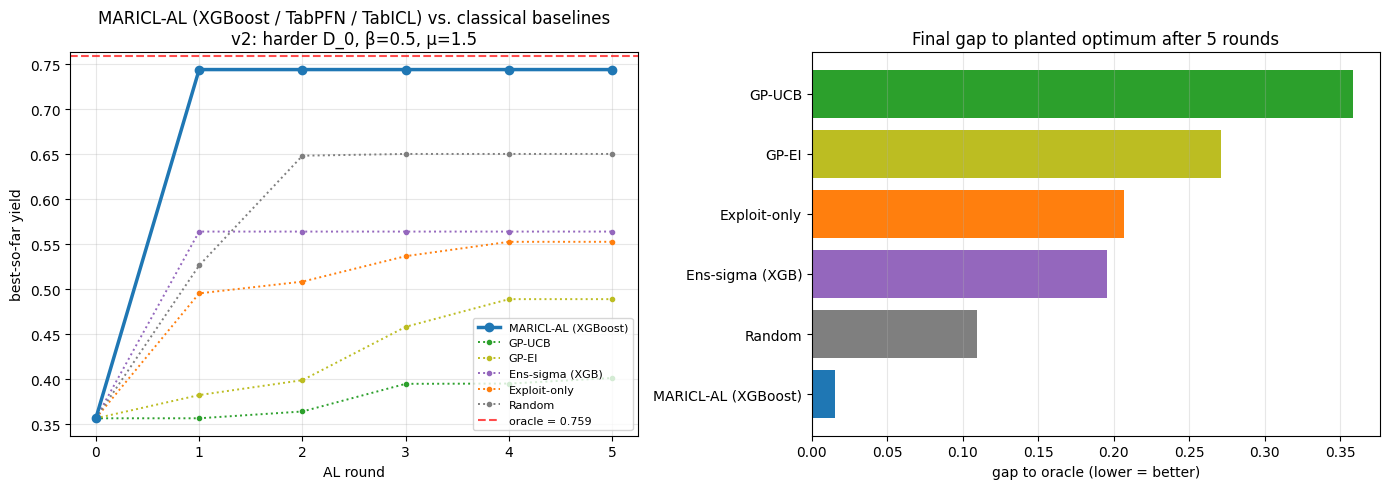

In [40]:
# reassemble ALL so this cell can run independently after a kernel restart
_g = globals()
ALL = [r for r in [
    _g.get('res_xgb'),
    _g.get('res_tabpfn') if not _g.get('SKIP_TABPFN', True) else None,
    _g.get('res_tabicl') if not _g.get('SKIP_TABICL', True) else None,
    _g.get('res_gp_ucb'), _g.get('res_gp_ei'),
    _g.get('res_ens_unc'), _g.get('res_exploit'), _g.get('res_random'),
] if r is not None]
if not ALL:
    raise RuntimeError("No results in memory — run the 'Run all' cell first.")
R = _g.get('R', len(ALL[0].best_so_far) - 1)

COLORS = {
    "MARICL-AL (XGBoost)":  "tab:blue",
    "MARICL-AL (TabPFN)":   "tab:cyan",
    "MARICL-AL (TabICL)":   "tab:teal",
    "GP-UCB":               "tab:green",
    "GP-EI":                "tab:olive",
    "Ens-sigma (XGB)":      "tab:purple",
    "Exploit-only":         "tab:orange",
    "Random":               "tab:gray",
}
STYLES = {
    "MARICL-AL (XGBoost)": dict(lw=2.5, ls="-",  marker="o", zorder=5),
    "MARICL-AL (TabPFN)":  dict(lw=2.5, ls="--", marker="s", zorder=5),
    "MARICL-AL (TabICL)":  dict(lw=2.5, ls="-.", marker="^", zorder=5),
}

rounds = np.arange(R + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for r in ALL:
    kw = STYLES.get(r.name, dict(lw=1.4, ls=":", marker=".", zorder=3))
    axes[0].plot(rounds, r.best_so_far,
                 color=COLORS.get(r.name, "k"), label=r.name, **kw)
axes[0].axhline(ORACLE_YIELD, ls="--", color="red", alpha=0.7,
                label=f"oracle = {ORACLE_YIELD:.3f}")
axes[0].set_xlabel("AL round")
axes[0].set_ylabel("best-so-far yield")
axes[0].set_title("MARICL-AL (XGBoost / TabPFN / TabICL) vs. classical baselines\n"
                  "v2: harder D_0, β=0.5, μ=1.5")
axes[0].set_xticks(rounds)
axes[0].grid(alpha=0.3)
axes[0].legend(loc="lower right", fontsize=8)

names  = [r.name for r in ALL]
gaps   = [ORACLE_YIELD - r.best_so_far[-1] for r in ALL]
cols   = [COLORS.get(n, "k") for n in names]
order  = np.argsort(gaps)
axes[1].barh([names[i] for i in order], [gaps[i] for i in order],
             color=[cols[i] for i in order])
axes[1].set_xlabel("gap to oracle (lower = better)")
axes[1].set_title("Final gap to planted optimum after 5 rounds")
axes[1].grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()


## 8. Inspect what MARICL-AL learned

In [41]:
for t, tmpls in enumerate(res_xgb.templates_per_round):
    print(f"\n=== Round {t} templates ===")
    for k, T in enumerate(tmpls):
        print(f"  [{k}] {T}")



=== Round 0 templates ===
  [0] The yield correction accounts for nonlinear saturation effects of NTPs and amino acids, Gaussian optima for cofactors Mg and DTT, and a subtractive toxicity effect from PEG. By modeling these interactions multiplicatively, the correction captures the complex relationships and synergies that influence CFPS yield more accurately.
  [1] The yield correction accounts for the saturation effects of primary substrates using Michaelis-Menten kinetics, while incorporating Gaussian-optimum relationships for cofactors to reflect their optimal concentrations. Additionally, it includes a synergy term for cofactors to enhance yield predictions and a penalty for high PEG concentrations to mitigate toxicity effects.

=== Round 1 templates ===
  [0] (none)
  [1] The yield correction model integrates Michaelis-Menten kinetics for substrate saturation and Gaussian functions for cofactor dependencies, while also accounting for synergistic interactions and penalties for hig

In [42]:
print("Final corrections:")
for k, (s, p) in enumerate(zip(maricl_xgb.states_, maricl_xgb.scores_)):
    print(f"\n--- correction {k}  (p_k={p:.3f}, best at iter {s.best_t}) ---")
    print(f"T_k: {s.best_correction.T_k}")
    print(f"f_k: {s.best_correction.f_k}")


Final corrections:

--- correction 0  (p_k=0.509, best at iter 0) ---
T_k: The yield correction accounts for saturation effects of NTPs and amino acids through a Michaelis-Menten-like function, while incorporating Gaussian-optimum behavior for cofactors Mg and DTT. It also includes a quadratic penalty for PEG toxicity above a critical threshold, ensuring that the model captures complex interactions and dependencies effectively.
f_k: clip(mm(x_NTP, 0.2), -0.4, 0.4) * gauss(x_Mg, 0.5, 0.1) * gauss(x_DTT, 0.5, 0.1) + x_NAD * x_spm - clip((x_PEG - 0.7)**2, 0, 0.4)

--- correction 1  (p_k=0.585, best at iter 0) ---
T_k: The yield correction incorporates Michaelis-Menten saturation for NTPs, Gaussian dependencies for cofactors like Mg and DTT, and a synergistic effect between NAD and spermidine. Additionally, it accounts for the toxicity of PEG-8000 concentrations exceeding a threshold, ensuring the correction remains bounded within the specified output range.
f_k: clip(mm(x_NTP, 0.1) * exp(

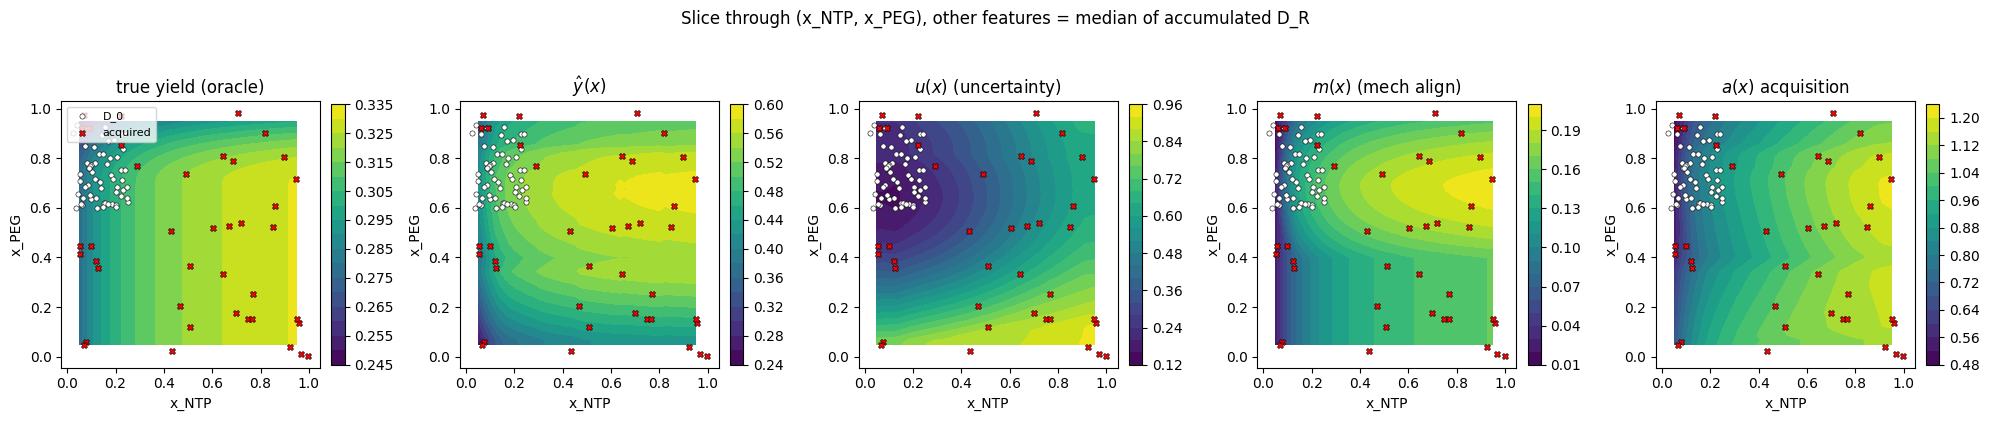

In [43]:
# acquisition components on a (x_NTP, x_PEG) slice, all other features = median of D_R
xx, yy = np.meshgrid(np.linspace(0.05, 0.95, 50), np.linspace(0.05, 0.95, 50))
median_x = np.median(res_xgb.X_hist[-1], axis=0)
grid = np.tile(median_x, (xx.size, 1))
grid[:, 0] = xx.ravel(); grid[:, 5] = yy.ravel()

y_hat = maricl_xgb.predict(grid).reshape(xx.shape)
u, _, _ = epistemic_uncertainty(grid, res_xgb.X_hist[-1], maricl_xgb)
u = u.reshape(xx.shape)
m_x = mechanism_alignment(grid, maricl_xgb).reshape(xx.shape)
a = (y_hat + 0.5*u + 1.5*m_x)
y_true = cfps_true_yield(grid, noise_std=0).reshape(xx.shape)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
Xall = res_xgb.X_hist[-1]
for ax, Z, name in zip(axes,
                       [y_true, y_hat, u, m_x, a],
                       ["true yield (oracle)", "$\\hat y(x)$",
                        "$u(x)$ (uncertainty)", "$m(x)$ (mech align)", "$a(x)$ acquisition"]):
    im = ax.contourf(xx, yy, Z, 20, cmap="viridis")
    ax.scatter(Xall[:len(X0), 0], Xall[:len(X0), 5], c="white", edgecolor="k", s=14,
               label="D_0", lw=0.4)
    if len(Xall) > len(X0):
        ax.scatter(Xall[len(X0):, 0], Xall[len(X0):, 5], c="red", edgecolor="k", s=20,
                   marker="X", label="acquired", lw=0.4)
    ax.set_xlabel("x_NTP"); ax.set_ylabel("x_PEG"); ax.set_title(name)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
axes[0].legend(loc="upper left", fontsize=8)
plt.suptitle("Slice through (x_NTP, x_PEG), other features = median of accumulated D_R", y=1.04)
plt.tight_layout(); plt.show()
